# Example 15: VC Dimension

The Vapnik-Chervonenkis (VC) dimension measures how flexible a hypothesis set is in fitting different datasets, making it a key concept in statistical learning. It represents the largest number of points a hypothesis set can accurately classify, regardless of how those points are labeled.

- **Bounds**: The VC dimension provides upper and lower bounds on the number of training examples needed for a given level of accuracy.
- **Applications**: It's used to assess model complexity in machine learning, including neural networks and decision trees. It also helps design robust learning algorithms and applies to other computer science areas.
- **Implementation**: While the VC dimension is a theoretical concept, we can estimate it in Python by counting points a hypothesis set can shatter. This is done using a brute-force approach to check all possible point and label combinations.

Let's illustrate this concept with an example.  

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import itertools

# Needed to compute VC dimension of these model types
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

# Needed to provide type hints for functions passed as arguments
from typing import Callable

Given a dataset of points, we need to classify these points as belonging to one of two groups. We will then test if these groupings can be divided by the specific model type. 

In [2]:
def generate_groupings(points:list) -> list[dict]:
    """
    Generate all possible dichotomous groupings of a set of points
    """
    
    classifications = []
    
    for combo in itertools.product([-1, 1], repeat=len(points)):

        if all(val == combo[0] for val in combo):
            continue  # Remove cases when only one grouping
        
        classification = {} # Dictionary assigns point to classification
        
        for i, point in enumerate(points):
            classification[tuple(point)] = combo[i]
            
        classifications.append(classification)
        
    return classifications

To illustrate how this function works, let's demonstrate with an example. 

In [3]:
points = [(1, 0), (0, 1), (1, 1), (1, 2)]
results = generate_groupings(points)

# Print classification
for dictionary in results:
    print(dictionary)

{(1, 0): -1, (0, 1): -1, (1, 1): -1, (1, 2): 1}
{(1, 0): -1, (0, 1): -1, (1, 1): 1, (1, 2): -1}
{(1, 0): -1, (0, 1): -1, (1, 1): 1, (1, 2): 1}
{(1, 0): -1, (0, 1): 1, (1, 1): -1, (1, 2): -1}
{(1, 0): -1, (0, 1): 1, (1, 1): -1, (1, 2): 1}
{(1, 0): -1, (0, 1): 1, (1, 1): 1, (1, 2): -1}
{(1, 0): -1, (0, 1): 1, (1, 1): 1, (1, 2): 1}
{(1, 0): 1, (0, 1): -1, (1, 1): -1, (1, 2): -1}
{(1, 0): 1, (0, 1): -1, (1, 1): -1, (1, 2): 1}
{(1, 0): 1, (0, 1): -1, (1, 1): 1, (1, 2): -1}
{(1, 0): 1, (0, 1): -1, (1, 1): 1, (1, 2): 1}
{(1, 0): 1, (0, 1): 1, (1, 1): -1, (1, 2): -1}
{(1, 0): 1, (0, 1): 1, (1, 1): -1, (1, 2): 1}
{(1, 0): 1, (0, 1): 1, (1, 1): 1, (1, 2): -1}


Next, given a classification, is it possible for the specific model to shatter that classification? 

In [4]:
def can_line_shatter(points:list, grouping:list[dict]):
    """
    Check if a linear classifier can shatter a given dichotomy.
    """
    
    X = np.array([list(point) for point in grouping.keys()])
    y = np.array(list(grouping.values()))
    line = LinearRegression().fit(X, y)
    predictions = np.sign(line.predict(X))
    
    return np.array_equal(predictions, y)

The above function is attempting to determine if the above model can correctly classify the given grouping of points. Below is an example of the set of points and a given grouping. We can see that the model can effectively separate these four points. 

In [5]:
print(results[3])
print(can_line_shatter(points, results[3]))

{(1, 0): -1, (0, 1): 1, (1, 1): -1, (1, 2): -1}
True


We can now use these two functions to compute the VC dimension of linear regressions. To do this, we need to count how many of the data points can we effectively separate with the given model-type. 

In [6]:
def find_vc_dimension(points:list, can_shatter:Callable) -> int:
    """
    Returns the VC dimension of classifier provided
    """
    
    for num_of_points in range(2, len(points)+1):
        split_test_cases = generate_groupings(points[:num_of_points])
        if not all(can_shatter(points[:num_of_points], d) for d in split_test_cases):
            return num_of_points - 1
            
    return num_of_points

We can now provide a test to illustrate that the VC dimension for linear regression is 3:

In [7]:
np.random.seed(15)

# Create random 2D points
points = np.random.uniform(low=(0, 0), high=(10, 10), size=(6, 2))

# Calculate VC dimension of linear regression models
vc_dim = find_vc_dimension(points, can_line_shatter)
print(vc_dim)

3


Although this is not necessary, let's graph all the lines generated with the ponts in the previous example. 

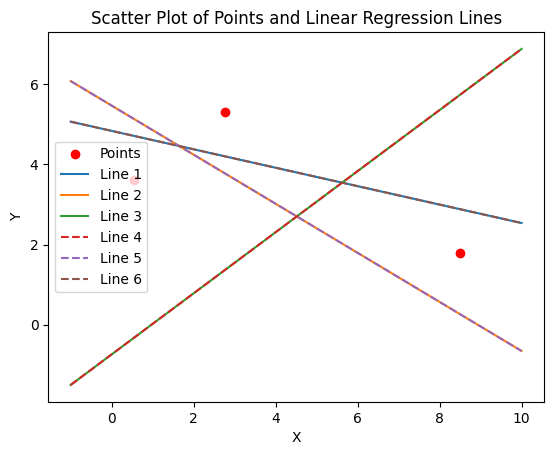

In [8]:
split_test_cases = generate_groupings(points[:vc_dim])

lines = []
for grouping in split_test_cases:
    X = np.array([list(point) for point in grouping.keys()])
    y = np.array(list(grouping.values()))
    line = LinearRegression().fit(X, y)
    lines.append(LinearRegression().fit(X, y))

# Extract x and y coordinates from the points
x_coords, y_coords = zip(*points[:vc_dim])
    
# Scatter plot for points
plt.scatter(x_coords, y_coords, label='Points', color='red')

# Plot the linear regression lines
for i, line in enumerate(lines):
    x_range = np.linspace(-1, 10, 400)
    y_pred = -(line.intercept_ + line.coef_[0] * x_range) / line.coef_[1]
    if i<3:
        plt.plot(x_range, y_pred, label=f'Line {i + 1}')
    else:
        plt.plot(x_range, y_pred, '--', label=f'Line {i + 1}')

plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Scatter Plot of Points and Linear Regression Lines')
plt.show()

If we define a similar setup for a different modeling technique. For example, let's consider Logistic regression. 

In [9]:
def can_logistic_shatter(points:list, grouping:list[dict]) -> bool:
    """
    Check if a logistic classifier can shatter a given dichotomy.
    """
    
    X = np.array([list(point) for point in grouping.keys()])
    y = np.array(list(grouping.values()))
    
    line = LogisticRegression().fit(X, y)
    predictions = np.sign(line.predict(X))
    
    return np.array_equal(predictions, y)

Now we can perform the same test for this modeling technique and compute its VC dimension. 

In [10]:
# Create random 2D points
points = [(0, 0), (2, 0), (1, 2), (2, 2)]

# Calculate VC dimension of linear regression models
print(find_vc_dimension(points, can_logistic_shatter))


3


For some cases of points, the VC dimension will either be 3 or 2 for logistic regression. A good exercise is to see what types of points will yield these results. 